In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(sys.path[:3])

c:\Users\Dinesh\OneDrive\Desktop\Microfinance-Fraud-Detection
['c:\\Users\\Dinesh\\OneDrive\\Desktop\\Microfinance-Fraud-Detection', 'C:\\Users\\Dinesh\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\Dinesh\\AppData\\Local\\Programs\\Python\\Python311\\DLLs']


In [6]:
import joblib

preprocessor = joblib.load("../models/preprocessor.pkl")
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [7]:
import src.transformers

print("Import Success")

Import Success


In [8]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [9]:
from pathlib import Path
import joblib

MODELS_DIR = Path("../models")

print(MODELS_DIR.resolve())
print(MODELS_DIR.exists())

C:\Users\Dinesh\OneDrive\Desktop\Microfinance-Fraud-Detection\models
True


In [10]:
best_model = joblib.load(MODELS_DIR / "best_model.pkl")
meta = joblib.load(MODELS_DIR / "best_model_meta.pkl")


X_test = joblib.load(MODELS_DIR / "X_test.pkl")
y_test = joblib.load(MODELS_DIR / "y_test.pkl")

print(meta)

{'name': 'HistGradientBoosting (Tuned)', 'threshold': 0.08703703010154923, 'pr_auc_on_test': 0.09445474781826506}


In [11]:
threshold = meta["threshold"]

y_prob = best_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= threshold).astype(int)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9697
           1       0.16      0.17      0.16       303

    accuracy                           0.95     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.95      0.95      0.95     10000



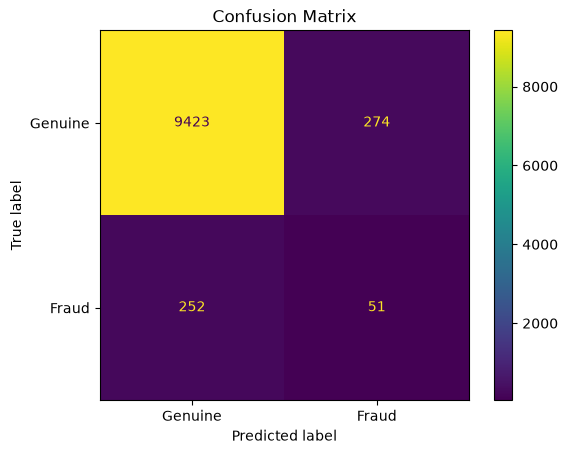

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

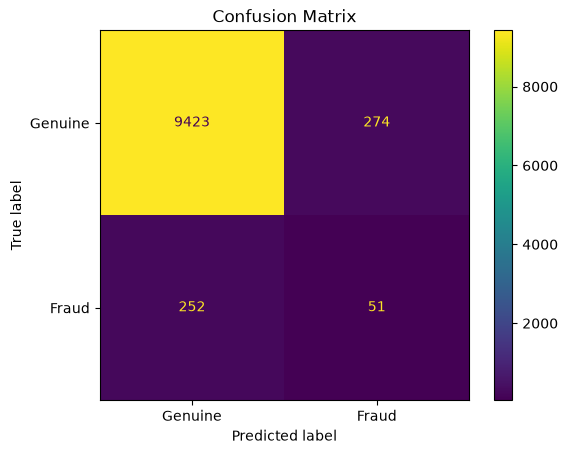

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

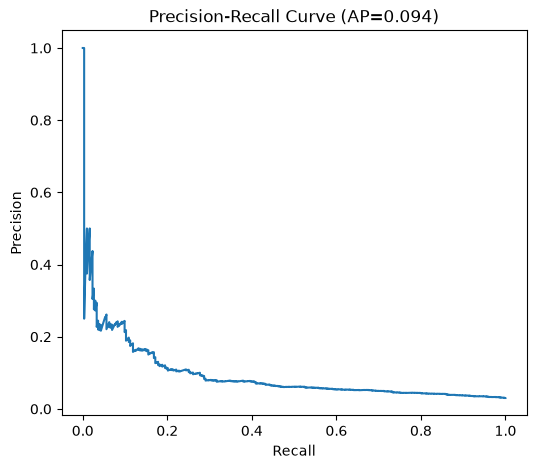

In [15]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.title(f"Precision-Recall Curve (AP={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [17]:
print(type(X_test))
print(type(best_model))

<class 'numpy.ndarray'>
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


In [18]:
from pathlib import Path

print(Path.cwd())
print((Path.cwd().parent / "src").exists())

c:\Users\Dinesh\OneDrive\Desktop\Microfinance-Fraud-Detection\production_pipeline
True


In [19]:
import joblib

preprocessor = joblib.load("../models/preprocessor.pkl")

print(type(preprocessor))


<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [20]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(len(result.importances_mean))

139
139


In [21]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
36,num__blacklist_match,0.031558
39,num__kyc_completeness,0.029889
40,num__document_verification_score,0.013959
37,num__duplicate_application,0.011095
32,num__sim_card_changes,0.007861
38,num__identity_verification_failed,0.006905
47,num__network_risk_score,0.004979
48,num__typing_speed_anomaly,0.003620
27,num__unusual_transaction_ratio,0.002209
54,num__credit_utilization_ratio,0.001770


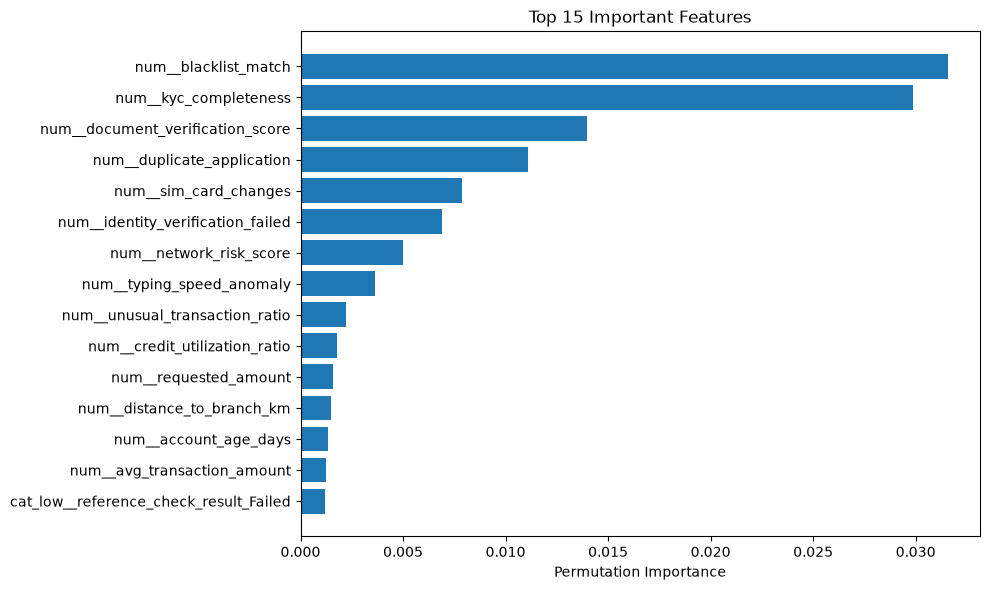

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(15)[::-1],
    importance_df["Importance"].head(15)[::-1]
)

plt.xlabel("Permutation Importance")
plt.title("Top 15 Important Features")

plt.tight_layout()
plt.show()

## Business Interpretation

- The model correctly identified **51 fraudulent transactions**.
- It missed **252 fraud cases**, indicating there is room to improve recall.
- It incorrectly flagged **274 genuine transactions** as fraud.
- The model achieved a **Test PR-AUC of 0.094**, which is a more meaningful metric than accuracy for this highly imbalanced dataset.
- Hyperparameter tuning improved PR-AUC and F1 compared to the baseline HistGradientBoosting model.

In [23]:
evaluation_metrics = {
    "Model": meta["name"],
    "Threshold": meta["threshold"],
    "Test PR-AUC": meta["pr_auc_on_test"],
}

pd.DataFrame([evaluation_metrics])

,Model,Threshold,Test PR-AUC
0,HistGradientBoosting (Tuned),0.087037,0.094455


In [24]:
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

pd.DataFrame([evaluation_metrics]).to_csv(
    REPORTS_DIR / "model_evaluation.csv",
    index=False
)

print("Evaluation report saved successfully.")

Evaluation report saved successfully.


# Final Conclusion

The final selected model is **HistGradientBoostingClassifier** with optimized hyperparameters and threshold tuning.

## Highlights

- Dataset: 50,000 records
- Fraud Rate: ~3%
- Best Model: HistGradientBoostingClassifier
- Hyperparameter Tuned: Yes
- Threshold Optimized: Yes
- Test PR-AUC: 0.094
- Precision: 0.16
- Recall: 0.17
- F1 Score: 0.16

The project followed a complete machine learning workflow including:

- Data Understanding
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Data Preprocessing
- Model Comparison
- Hyperparameter Tuning
- Threshold Optimization
- Model Evaluation

The trained model and preprocessing pipeline are saved and ready for deployment.

In [25]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")   # notebook nundi run chesthe

preprocessor = joblib.load(MODELS_DIR / "preprocessor.pkl")

print(preprocessor.feature_names_in_)

['branch_id' 'customer_age' 'gender' 'marital_status' 'education_level'
 'occupation' 'annual_income' 'monthly_expenses' 'credit_score'
 'years_with_institution' 'previous_loan_count' 'dependents'
 'home_ownership' 'mobile_registered' 'region' 'state'
 'distance_to_branch_km' 'branch_transaction_volume'
 'branch_fraud_rate_history' 'loan_purpose' 'requested_amount'
 'loan_term_months' 'interest_rate' 'loan_to_income_ratio'
 'collateral_provided' 'guarantors_count' 'group_lending'
 'application_channel' 'processing_time_days' 'device_type' 'browser_type'
 'network_type' 'debt_service_ratio' 'avg_monthly_transactions'
 'avg_transaction_amount' 'total_transaction_volume'
 'transaction_velocity' 'cash_out_percentage'
 'suspicious_transaction_count' 'high_value_transaction_flag'
 'unusual_transaction_ratio' 'app_login_frequency'
 'app_login_anomaly_score' 'device_changes' 'ip_changes'
 'sim_card_changes' 'account_age_days' 'failed_login_attempts'
 'biometric_verification' 'blacklist_match' 